<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Uso como dataset el libro Moby-Dick que bajo de Project Gutenberg.

In [2]:
import requests

In [3]:
# Descargo el libro
url = "https://www.gutenberg.org/cache/epub/2701/pg2701.txt"

response = requests.get(url)
text = response.text

# Saco encabezado y pie de Project Gutenberg

start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK MOBY DICK; OR, THE WHALE ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK MOBY DICK; OR, THE WHALE ***"

start = text.find(start_marker)
end = text.find(end_marker)

if start != -1:
    text_clean = text[start + len(start_marker):]
else:
    text_clean = text

if end != -1:
    text_clean = text_clean[:text_clean.find(end_marker)]

text_clean = text_clean.strip()

# Chequeo inicio y fin del texto

print("INICIO:")
print(text_clean[:1000])

print("\n" + "="*80 + "\n")

print("FINAL:")
print(text_clean[-1000:])

INICIO:
MOBY-DICK;

or, THE WHALE.

By Herman Melville



CONTENTS

ETYMOLOGY.

EXTRACTS (Supplied by a Sub-Sub-Librarian).

CHAPTER 1. Loomings.

CHAPTER 2. The Carpet-Bag.

CHAPTER 3. The Spouter-Inn.

CHAPTER 4. The Counterpane.

CHAPTER 5. Breakfast.

CHAPTER 6. The Street.

CHAPTER 7. The Chapel.

CHAPTER 8. The Pulpit.

CHAPTER 9. The Sermon.

CHAPTER 10. A Bosom Friend.

CHAPTER 11. Nightgown.

CHAPTER 12. Biographical.

CHAPTER 13. Wheelbarrow.

CHAPTER 14. Nantucket.

CHAPTER 15. Chowder.

CHAPTER 16. The Ship.

CHAPTER 17. The Ramadan.

CHAPTER 18. His Mark.

CHAPTER 19. The Prophet.

CHAPTER 20. All Astir.

CHAPTER 21. Going Aboard.

CHAPTER 22. Merry Christmas.

CHAPTER 23. The Lee Shore.

CHAPTER 24. The Advocate.

CHAPTER 25. Postscript.

CHAPTER 26. Knights and Squires.

CHAPTER 27. Knights and Squires.

CHAPTER 28. Ahab.

CHAPTER 29. Enter Ahab; to Him, Stubb.

CHAPTER 30. The Pipe.

CHAPTER 31. Queen Mab


FINAL:
nt suction of the sunk ship reached me, I was then, but


### 1 - Preprocesamiento

In [4]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

sentences = sent_tokenize(text_clean)

sentence_tokens = []

for sentence in sentences:
    sentence = sentence.lower()
    sentence = sentence.replace("-", " ") # Lo agrego porque isalpha borraba "moby-dick"
    
    tokens = word_tokenize(sentence)
    tokens = [token for token in tokens if token.isalpha()]
    
    if len(tokens) >= 3:
        sentence_tokens.append(tokens)

for tokens in sentence_tokens[:10]:
    print(tokens)

[nltk_data] Downloading package punkt to /home/ronald/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ronald/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['moby', 'dick', 'or', 'the', 'whale']
['by', 'herman', 'melville', 'contents', 'etymology']
['extracts', 'supplied', 'by', 'a', 'sub', 'sub', 'librarian']
['the', 'carpet', 'bag']
['the', 'spouter', 'inn']
['a', 'bosom', 'friend']
['the', 'lee', 'shore']
['knights', 'and', 'squires']
['knights', 'and', 'squires']
['enter', 'ahab', 'to', 'him', 'stubb']


### 2 - Crear los vectores (word2vec)

In [5]:
from gensim.models.callbacks import CallbackAny2Vec
# Mantenemos la clase auxiliar para monitorear loss
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [6]:
# Crearmos el modelo generador de vectores

w2v_model = Word2Vec(
                    min_count=5,    # quito palabras que aparezcan menos de 5 veces
                    window=5,       # amplío a 5 la ventana porque es texto literario
                    vector_size=300,       # mantengo la dimensionalidad de los vectores en 300
                    negative=20,    # cantidad de negative samples... 0 es no se usa
                    workers=4,      # tengo 8 workers, pongo 4 para ir más rápido
                    sg=1            # Uso skipgram
                    )

In [7]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [8]:
# Cantidad de oraciones y palabras encontradas en el corpus
print("Cantidad de oraciones en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de oraciones en el corpus: 8083
Cantidad de words distintas en el corpus: 4161


### 3 - Entrenar embeddings

In [9]:
# Entreno el modelo generador de vectores
w2v_model.train(
                sentence_tokens,
                total_examples=w2v_model.corpus_count,
                epochs=30,
                compute_loss = True,
                callbacks=[callback()]
                )

Loss after epoch 0: 857515.3125
Loss after epoch 1: 707494.0625
Loss after epoch 2: 675332.625
Loss after epoch 3: 586586.0
Loss after epoch 4: 619960.25
Loss after epoch 5: 607322.25
Loss after epoch 6: 569389.0
Loss after epoch 7: 468544.0
Loss after epoch 8: 560824.0
Loss after epoch 9: 545192.0
Loss after epoch 10: 545773.0
Loss after epoch 11: 538744.0
Loss after epoch 12: 540255.0
Loss after epoch 13: 539218.0
Loss after epoch 14: 514590.5
Loss after epoch 15: 505643.0
Loss after epoch 16: 509757.0
Loss after epoch 17: 500057.0
Loss after epoch 18: 496025.0
Loss after epoch 19: 469426.0
Loss after epoch 20: 471354.0
Loss after epoch 21: 497167.0
Loss after epoch 22: 489715.0
Loss after epoch 23: 493482.0
Loss after epoch 24: 491175.0
Loss after epoch 25: 487212.0
Loss after epoch 26: 492614.0
Loss after epoch 27: 487953.0
Loss after epoch 28: 483293.0
Loss after epoch 29: 479727.0


(4179572, 6493980)

### 4 - Ensayar

In [10]:
# Palabras que MÁS se relacionan con...:
words = ["whale", "ship", "sea", "ahab", "ishmael", "moby", "captain", "boat", "ronald"]

for word in words:
    print("=" * 30)
    
    if word in w2v_model.wv:
        print(f"Palabras similares a '{word}':")
        print("-" * 30)
        
        similar = w2v_model.wv.most_similar(word, topn=5)
        
        for similar_word, score in similar:
            print(f"{similar_word:20s} {score:.3f}")
            
    else:
        print(f"'{word}' no está en el vocabulario")

Palabras similares a 'whale':
------------------------------
designated           0.462
beheaded             0.460
sperm                0.451
elephant             0.416
beale                0.415
Palabras similares a 'ship':
------------------------------
ding                 0.424
vessel               0.401
schooner             0.383
wharf                0.366
timbers              0.365
Palabras similares a 'sea':
------------------------------
pool                 0.383
coral                0.363
swell                0.361
prairies             0.352
timbers              0.350
Palabras similares a 'ahab':
------------------------------
pacing               0.415
mayhew               0.393
affairs              0.355
parsee               0.353
fiend                0.353
Palabras similares a 'ishmael':
------------------------------
explain              0.562
lest                 0.561
langsdorff           0.554
brave                0.536
furthermore          0.532
Palabras similares a '

In [11]:
# Palabras que MENOS se relacionan con...:
words = ["whale", "ship", "sea", "ahab", "ishmael", "moby", "captain", "boat", "ronald"]

for word in words:
    print("=" * 40)
    
    if word in w2v_model.wv:
        print(f"Palabras menos relacionadas con '{word}':")
        print("-" * 40)
        
        not_similar = w2v_model.wv.most_similar(negative=[word], topn=5)
        
        for not_similar_word, score in not_similar:
            print(f"{not_similar_word:20s} {score:.3f}")
            
    else:
        print(f"'{word}' no está en el vocabulario")

Palabras menos relacionadas con 'whale':
----------------------------------------
sweet                -0.016
strong               -0.022
putting              -0.030
across               -0.030
meals                -0.035
Palabras menos relacionadas con 'ship':
----------------------------------------
crooked              -0.005
light                -0.007
concerning           -0.007
repeated             -0.009
smoking              -0.016
Palabras menos relacionadas con 'sea':
----------------------------------------
rather               0.027
between              0.012
crow                 0.012
fine                 0.009
reserved             0.001
Palabras menos relacionadas con 'ahab':
----------------------------------------
bay                  0.008
commerce             0.004
numerous             0.001
copy                 -0.009
kept                 -0.009
Palabras menos relacionadas con 'ishmael':
----------------------------------------
wooden               0.047
blade        

### 5 - Visualizar agrupación de vectores

In [12]:
# Preparo la lista de stop words para mejorar la visualización
nltk.download("stopwords")

from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

# Agrego palabras antiguas frecuentes en Moby-Dick
extra_stopwords = {
    "thou", "thee", "thy", "ye", "unto", "upon", "hath", "shalt",
    "would", "could", "shall", "may", "might"
}

stop_words = stop_words.union(extra_stopwords)

[nltk_data] Downloading package stopwords to /home/ronald/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
# Reduzco los vectores a 2 dimensiones filtrando stop words

from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions_filtered(model, stop_words, num_dimensions = 2 ):

    filtered_vecs = []
    filtered_labels = []

    for word in model.wv.index_to_key:
        if word not in stop_words and len(word) > 2:
            filtered_labels.append(word)
            filtered_vecs.append(model.wv[word])

    filtered_vecs = np.asarray(filtered_vecs)
    filtered_labels = np.asarray(filtered_labels)

    tsne = TSNE(
                n_components=num_dimensions, 
                random_state=0
                )
    filtered_vecs = tsne.fit_transform(filtered_vecs)

    return filtered_vecs, filtered_labels

In [14]:
# Grafico los embedddings en 2D filtrados

import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions_filtered(w2v_model, stop_words)

MAX_WORDS=200
fig = px.scatter(
                x=vecs[:MAX_WORDS,0], 
                y=vecs[:MAX_WORDS,1], 
                text=labels[:MAX_WORDS],
                height=800,
                width=1200
                )
fig.show(renderer="vscode") # esto para plotly en vscode

**Capturas de pantalla y su interpretación**

Cerca de *whale* se encuentran las palabras *sperm* (uno de los productos de la caza de ballenas), *leviathan* (sinónimo de monstruo marino), *whalemen* (balleneros) y *found* (asociable a encontrar la presa de caza):

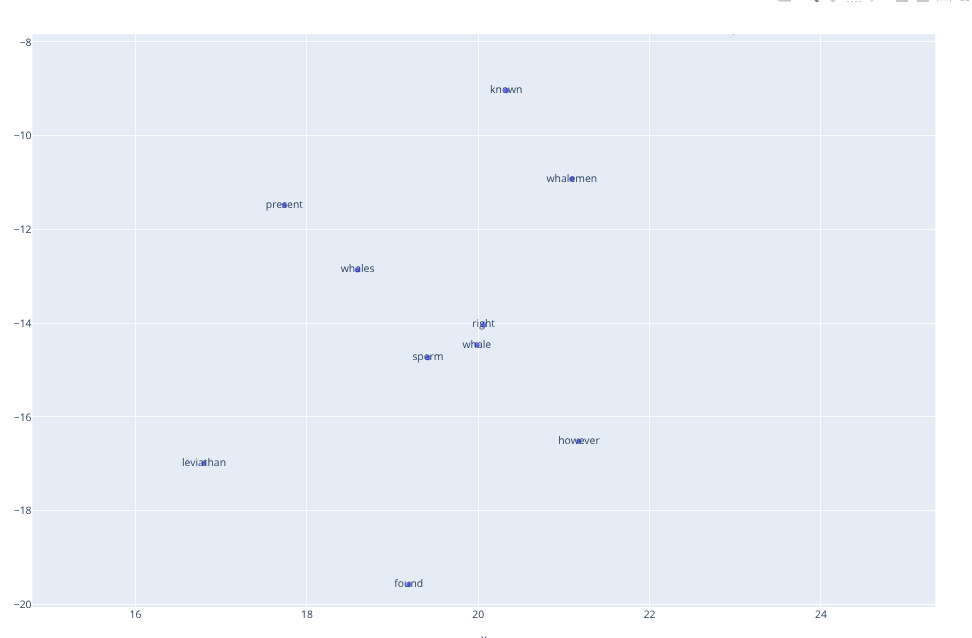


*Voyage*, *years* y *many* dan idea de viajes muy largos, característicos de las expediciones de caza de ballenas:

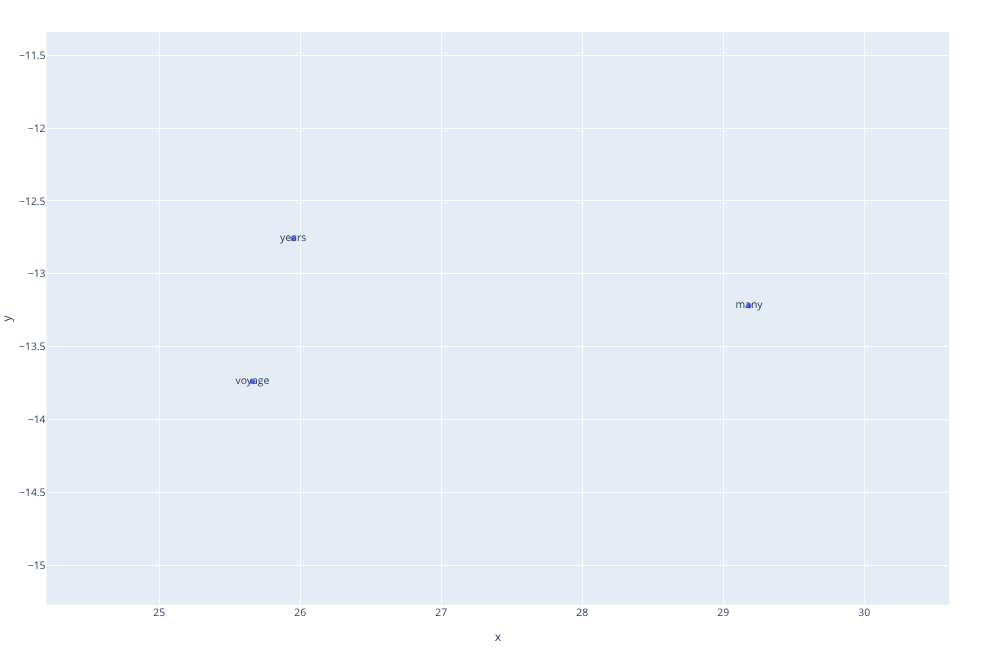


*dead*, *soul*, *heart* y *young* dan una idea del destino fatídico de la expedición (todos, salvo el narrador, mueren):

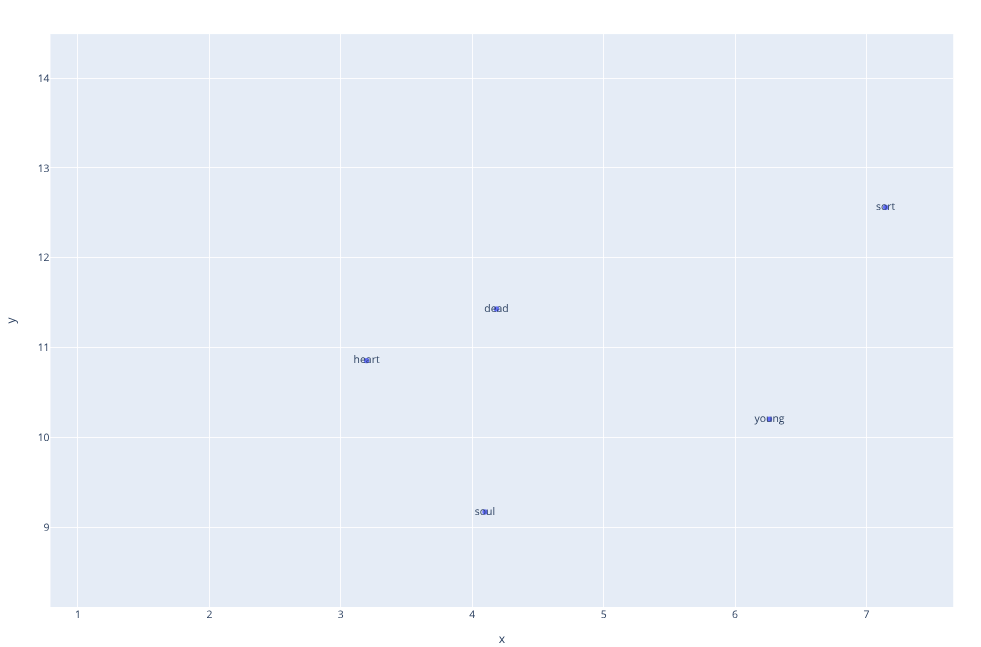


*seas* y *ocean* representan conceptos similares:

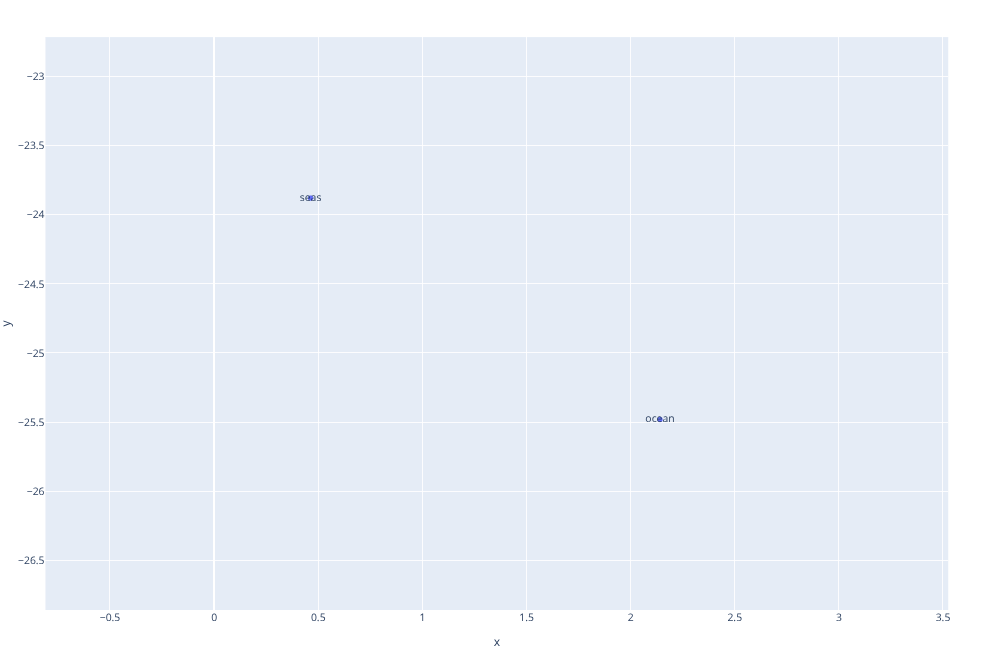


*deck* (cubierta) y *cabin* (cabina) son partes del barco:

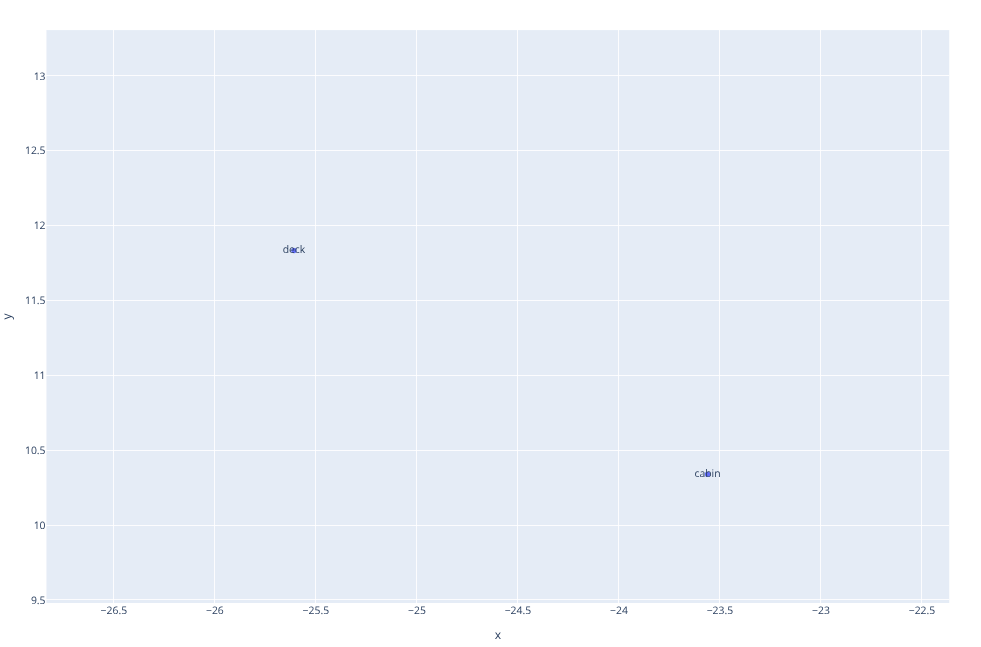


*starbuck* es e primer oficial del barco (*ship*) encargargado de gritar (*cried*) las órdenes a la tripulación (*men*):

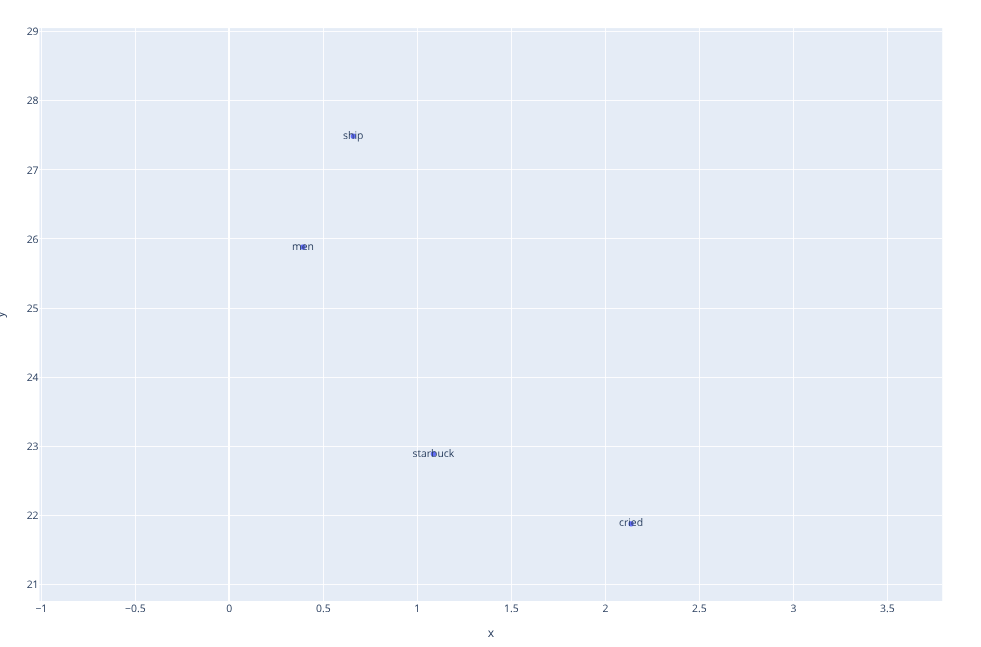


**Conclusiones**

Para poder ver adecuadamente los conceptos en 2D fue necesario quitar stop words, que no representan conceptos concretos e introducen mucho ruido en la gráfica. Encontré varios grupos de palabras que se corresponden con lo que ocurre en la narración. Notablemente, el grupo fatídico *dead*, *soul*, *heart* y *young* es el núcleo de la narración.
Los embeddings condensan información del texto, pero pltly es estocástico y los clusters de palabras cambian entre corridas, por lo que las conclusiones de estos gráficos deben usarse con precaución.